In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../MERS/')
from measurement import *

In [35]:
import numpy as np
from scipy.special import sph_harm

# -- Functions from previous cells (real_sph_harm, build_design_matrix, solve_modes) assumed defined here --

# Parameters
lmax = 10
B_l0 = np.exp(-np.arange(lmax + 1)**2 / (2 * 2**2))  # Simple Gaussian beam
# theta = np.arccos(np.random.uniform(-1, 1, 300))
theta = np.arccos(np.random.uniform(0, 1, 300))
# phi = np.random.uniform(0, 2*np.pi, 300)
phi = np.random.uniform(np.pi, 2*np.pi, 300)

# Generate design matrix
A, lm_list = build_design_matrix(theta, phi, B_l0, lmax)

# Generate synthetic sky coefficients (ground truth)
T_true = np.random.randn(len(lm_list))

# Simulate data
d = A @ T_true  # data = A * true coefficients

d_alt = evaluate_sky(theta, phi, T_true, lmax, B_l0=B_l0, complex_basis=False)

T_true_v2 = convert_real_to_complex_alm(T_true, lmax)
d_alt_v2 = evaluate_sky(theta, phi, T_true_v2, lmax, B_l0=B_l0, complex_basis=True)
# Add noise (optional)
# d += np.random.normal(0, 0.01, size=d.shape)


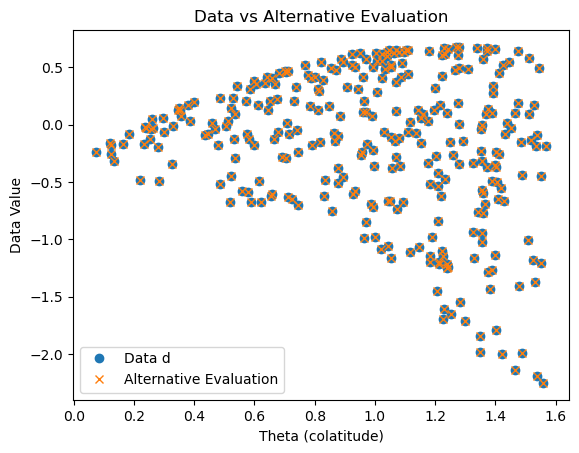

In [36]:
plt.plot(theta, d, 'o', label='Data d')
plt.plot(theta, d_alt, 'x', label='Alternative Evaluation')
plt.xlabel('Theta (colatitude)')
plt.ylabel('Data Value')
plt.legend()
plt.title('Data vs Alternative Evaluation')
plt.show()

In [37]:
# Solve inverse problem
T_est = solve_modes(A, d)

# Validate
error = np.linalg.norm(T_est - T_true) / np.linalg.norm(T_true)
print(f"Relative reconstruction error: {error:.2e}")

Relative reconstruction error: 3.53e-07


In [40]:
T_est.shape

(121,)

/var/folders/n6/tr4cmwxn5436s2wl6n6vtj240000gp/T/ipykernel_70945/1146170672.py:14: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sky_true = hp.alm2map(alm_true, nside, verbose=False)


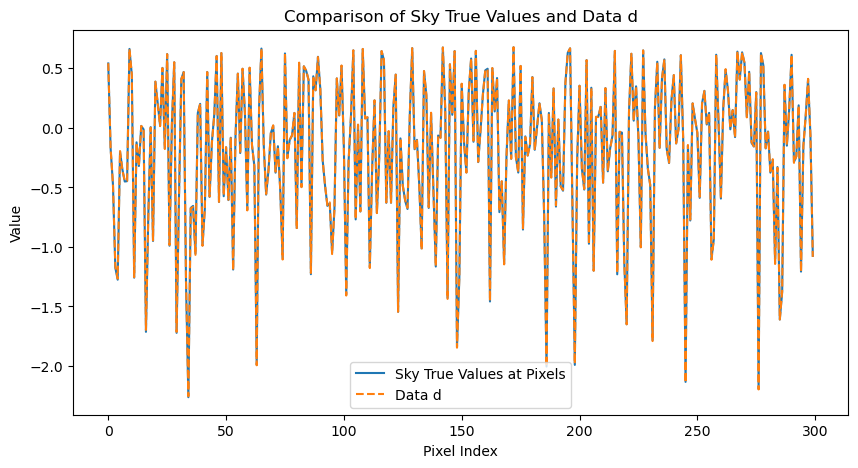

In [ ]:
# Convert T_est (array) to dict format for real_to_complex_alm
a_real_est_dict = {lm: coeff for lm, coeff in zip(lm_list, T_est)}

a_real_true_dict = {lm: coeff for lm, coeff in zip(lm_list, T_true)}

# Get alm array
alm_est = convert_real_to_complex_alm(T_est, lmax)
alm_true = convert_real_to_complex_alm(T_true, lmax)


# Map resolution
nside = 128  # or higher

sky_true = hp.alm2map(alm_true, nside, verbose=False)

norms = np.sqrt( 4 * np.pi / ( 2*np.arange(lmax + 1) + 1 ) ) # Normalization factors for each l
# Generate the map of sky_true convolved with the beam B_l0
sky_true_convolved = hp.smoothing(sky_true, beam_window=B_l0 * norms)

# Get the pixels of sky_true at theta, phi
theta_pix = theta  # Convert to colatitude
phi_pix = phi  # Azimuthal angle remains the same


# Get the pixel indices
pix_indices = hp.ang2pix(nside, theta_pix, phi_pix)

# Get the values at those pixels
sky_values = sky_true_convolved[pix_indices]
# Compare with d (plots)
plt.figure(figsize=(10, 5))
plt.plot(sky_values, label='Sky True Values at Pixels')
plt.plot(d, label='Data d', linestyle='--')
plt.xlabel('Pixel Index')
plt.ylabel('Value')
plt.title('Comparison of Sky True Values and Data d')
plt.legend()
plt.show()


In [44]:
# Validate
error = np.linalg.norm(sky_values - d) / np.linalg.norm(d)
print(f"Relative reconstruction error: {error:.2e}")

Relative reconstruction error: 7.27e-03


In [ ]:


# Generate full-sky map
sky_est = hp.alm2map(alm_est, nside, verbose=False)

# Plot
hp.mollview(sky_est, title="Recovered Sky Map")

/var/folders/n6/tr4cmwxn5436s2wl6n6vtj240000gp/T/ipykernel_65682/2305273004.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sky_true = hp.alm2map(alm_true, nside, verbose=False)


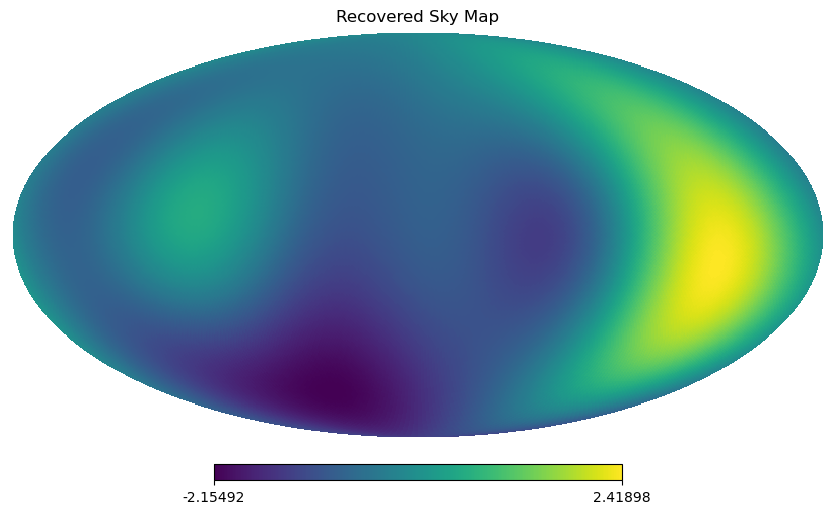

In [ ]:
hp.mollview(sky_true, title="Recovered Sky Map")

In [2]:
# Define directions (sky positions)
Nsky = 100
theta = np.arccos(np.random.uniform(-1, 1, Nsky))  # colatitude [0, pi]
phi = np.random.uniform(0, 2 * np.pi, Nsky)        # longitude [0, 2pi]

# Beam
lmax = 5
B_l0 = np.exp(-np.arange(lmax + 1)**2 / (2 * 3**2))  # e.g., Gaussian beam

# Build A
A, lm_list = build_design_matrix(theta, phi, B_l0, lmax)

print("Design matrix A shape:", A.shape)
print("First few (l,m):", lm_list[:10])

Design matrix A shape: (100, 36)
First few (l,m): [(0, 0), (1, -1), (1, 0), (1, 1), (2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3)]
